In [1]:
!pip install yfinance


In [2]:
!pip install nsepy

  Preparing metadata (setup.py) ... done
  Created wheel for nsepy: filename=nsepy-0.8-py3-none-any.whl size=36057 sha256=3d4eca79379b60c00ab200cfa9ff026e8479a0f66ab7149169d5d15ccf4f981b
  Stored in directory: /root/.cache/pip/wheels/ba/d6/a0/a2c830ea2a083f15d9790732c1908625dd6314a02f09a92130
Successfully built nsepy


In [4]:
from Descriptive import Descriptive

In [5]:
obj=Descriptive()

In [10]:
import datetime as dt
import pandas as pd
import yfinance as yf # Import yfinance

start = dt.datetime(2021,6,1)
end = dt.datetime(2022,1,5)

try:
    stk_data = yf.download('RELIANCE.NS', start=start, end=end) # '.NS' for NSE stocks
    if stk_data.empty:
        raise ValueError("yfinance returned an empty DataFrame. Check ticker or date range.")
except Exception as e:
    print(f"Error fetching data with yfinance: {e}")
    print("Could not fetch data using yfinance. Initializing an empty DataFrame.")
    stk_data = pd.DataFrame()

/tmp/ipykernel_458/67109835.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stk_data = yf.download('RELIANCE.NS', start=start, end=end) # '.NS' for NSE stocks
[*********************100%***********************]  1 of 1 completed


In [11]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 150 entries, 2021-06-01 to 2022-01-04
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   150 non-null    float64
 1   (High, RELIANCE.NS)    150 non-null    float64
 2   (Low, RELIANCE.NS)     150 non-null    float64
 3   (Open, RELIANCE.NS)    150 non-null    float64
 4   (Volume, RELIANCE.NS)  150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB


In [12]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-06-01,978.920959,993.860450,968.810795,977.612032,28013832
2021-06-02,993.521973,997.245564,973.549962,973.549962,24630162
2021-06-03,997.313232,1015.524983,991.197542,1002.435946,23974257
2021-06-04,988.669983,1000.382342,985.849055,999.637624,14468646
2021-06-07,1005.324585,1011.914231,986.187607,993.860485,16336573
...,...,...,...,...,...
2021-12-29,1088.135254,1095.608398,1078.895654,1082.926696,15425312
2021-12-30,1068.478638,1089.244946,1062.364269,1087.003003,29333171


In [13]:
low=stk_data["Low"]

In [14]:
dataset=stk_data
quan,qual=obj.segreQuanQual(dataset)

The Quantitative Data: [('Close', 'RELIANCE.NS'), ('High', 'RELIANCE.NS'), ('Low', 'RELIANCE.NS'), ('Open', 'RELIANCE.NS'), ('Volume', 'RELIANCE.NS')]
The Qualtitative Data []


In [15]:
des_data=obj.descriptive_Analysis(dataset,quan)

/content/Descriptive.py:24: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  des_data[i]["Count"]=len(dataset[i])
/content/Descriptive.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values thr

In [16]:
des_data

,"(Close, RELIANCE.NS)","(High, RELIANCE.NS)","(Low, RELIANCE.NS)","(Open, RELIANCE.NS)","(Volume, RELIANCE.NS)"
Count,150,150,150,150,150
Mean,1057.407553,1069.158082,1047.010465,1059.003777,14584981.813333
Median,1072.113281,1084.908218,1062.930438,1073.890937,12087939.0
Mode,944.786804,932.105071,913.195727,930.293368,1705656
Std,85.694076,87.654415,83.7422,86.07862,9640997.620994
Min,921.823792,932.105071,913.195727,930.293368,1705656.0
Q1:25%,979.032486,989.897375,968.116906,975.922094,9784558.0
Q2:50%,1072.113281,1084.908218,1062.930438,1073.890937,12087939.0
Q3:75%,1124.510345,1132.175955,1111.828506,1124.878224,15759452.75
Q4:100%,1237.303711,1246.13563,1226.501675,1242.240558,91461975.0


In [18]:
des_data[('Low', 'RELIANCE.NS')]

,Low
,RELIANCE.NS
Count,150
Mean,1047.010465
Median,1062.930438
Mode,913.195727
Std,83.7422
Min,913.195727
Q1:25%,968.116906
Q2:50%,1062.930438
Q3:75%,1111.828506


In [20]:
des_data[('High', 'RELIANCE.NS')]

,High
,RELIANCE.NS
Count,150
Mean,1069.158082
Median,1084.908218
Mode,932.105071
Std,87.654415
Min,932.105071
Q1:25%,989.897375
Q2:50%,1084.908218
Q3:75%,1132.175955


In [21]:
import numpy as np

In [24]:
np.percentile(dataset[('Low', 'RELIANCE.NS')],99)

np.float64(1218.0742058659328)

In [25]:
np.percentile(dataset[('High', 'RELIANCE.NS')],80)

np.float64(1146.26274821349)

In [54]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.histplot(dataset, kde=True, stat='density', line_kws={'color':'blue'}, color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    sample = dataset
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    dist = norm(sample_mean, sample_std)
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob

Mean=1047.010, Standard Deviation=83.742
The area between range(219,230):5.953501443727066e-23


/tmp/ipykernel_458/3993778407.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


np.float64(5.953501443727066e-23)

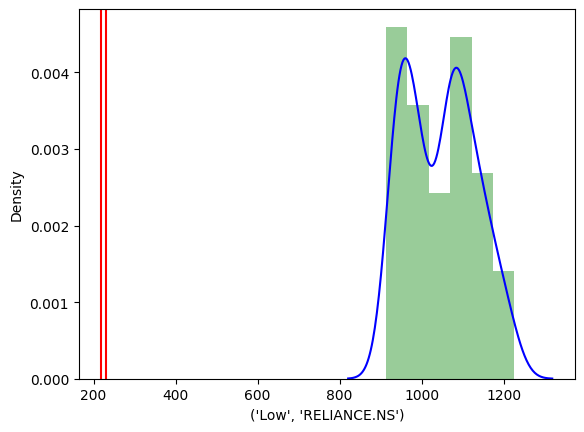

In [27]:
get_pdf_probability(dataset[('Low', 'RELIANCE.NS')],219,230)

In [50]:
def stdNBgraph(dataset):
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()

    values=[i for i in dataset]

    z_score=[((j-mean)/std) for j in values]

    sns.histplot(z_score, kde=True, stat='density')

    sum(z_score)/len(z_score)
    z_score.std()

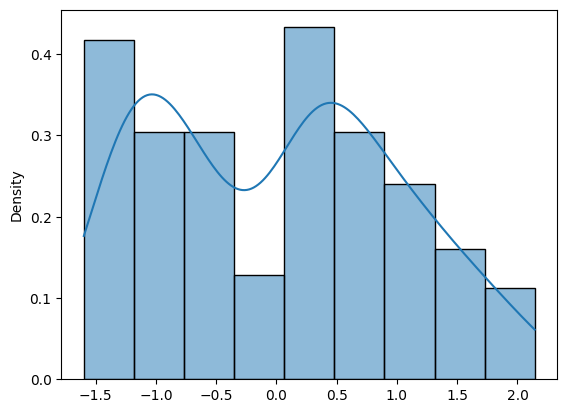

In [55]:
def stdNBgraph(dataset):
    import seaborn as sns
    import numpy as np
    mean=dataset.mean()
    std=dataset.std()

    values=[i for i in dataset]

    z_score=[((j-mean)/std) for j in values]

    sns.histplot(z_score, kde=True, stat='density')

    sum(z_score)/len(z_score)
    np.std(z_score)

stdNBgraph(dataset[('Low', 'RELIANCE.NS')])

In [49]:
def freqTable(columnName,dataset):
    import pandas as pd
    frq=pd.DataFrame()
    frq["Unique_Values"]=dataset[columnName].value_counts().index
    frq["Frequency"]=dataset[columnName].value_counts().values
    frq["Relative_Fre"]=dataset[columnName].value_counts().values/len(dataset[columnName])*100
    frq["Cumulative"]=frq["Relative_Fre"].cumsum()
    return frq

In [44]:
def freqTable(columnName,dataset):
    import pandas as pd
    frq=pd.DataFrame()
    frq["Unique_Values"]=dataset[columnName].value_counts().index
    frq["Frequency"]=dataset[columnName].value_counts().values
    frq["Relative_Fre"]=dataset[columnName].value_counts().values/len(dataset[columnName])*100
    frq["Cumulative"]=frq["Relative_Fre"].cumsum()
    return frq
freqTable(('Low', 'RELIANCE.NS'), dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,968.810795,1,0.666667,0.666667
1,973.549962,1,0.666667,1.333333
2,991.197542,1,0.666667,2.000000
3,985.849055,1,0.666667,2.666667
4,986.187607,1,0.666667,3.333333
...,...,...,...,...
145,1078.895654,1,0.666667,97.333333
146,1062.364269,1,0.666667,98.000000
147,1068.886227,1,0.666667,98.666667
148,1070.494046,1,0.666667,99.333333


In [45]:
def freqTable(columnName,dataset):
    import pandas as pd
    frq=pd.DataFrame()
    frq["Unique_Values"]=dataset[columnName].value_counts().index
    frq["Frequency"]=dataset[columnName].value_counts().values
    frq["Relative_Fre"]=dataset[columnName].value_counts().values/len(dataset[columnName])*100
    frq["Cumulative"]=frq["Relative_Fre"].cumsum()
    return frq
freqTable(('High', 'RELIANCE.NS'), dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,993.860450,1,0.666667,0.666667
1,997.245564,1,0.666667,1.333333
2,1015.524983,1,0.666667,2.000000
3,1000.382342,1,0.666667,2.666667
4,1011.914231,1,0.666667,3.333333
...,...,...,...,...
145,1095.608398,1,0.666667,97.333333
146,1089.244946,1,0.666667,98.000000
147,1079.710905,1,0.666667,98.666667
148,1090.603607,1,0.666667,99.333333


In [46]:
def freqTable(columnName,dataset):
    import pandas as pd
    frq=pd.DataFrame()
    frq["Unique_Values"]=dataset[columnName].value_counts().index
    frq["Frequency"]=dataset[columnName].value_counts().values
    frq["Relative_Fre"]=dataset[columnName].value_counts().values/len(dataset[columnName])*100
    frq["Cumulative"]=frq["Relative_Fre"].cumsum()
    return frq
fh=freqTable(('High', 'RELIANCE.NS'), dataset)

In [39]:
fh.sort_values(by="Frequency",ascending=False)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,993.860450,1,0.666667,0.666667
1,997.245564,1,0.666667,1.333333
2,1015.524983,1,0.666667,2.000000
3,1000.382342,1,0.666667,2.666667
4,1011.914231,1,0.666667,3.333333
...,...,...,...,...
145,1095.608398,1,0.666667,97.333333
146,1089.244946,1,0.666667,98.000000
147,1079.710905,1,0.666667,98.666667
148,1090.603607,1,0.666667,99.333333


In [41]:
fhs=fh[fh["Frequency"]==2]["Unique_Values"].sort_values(ascending=False)

In [42]:
fhs

,Unique_Values
